# DeepSpeech2 — Analiza podataka i rezultata

Ovaj notebook pokriva:
1. Exploratory Data Analysis (EDA) audio korpusa
2. Vizualizacija Log-Mel spektrograma
3. Analiza transkripata (dijakritici, distribucija duljina)
4. Vizualizacija rezultata treniranja (loss krivulje, WER/CER)
5. Analiza grešaka

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path("/home/dino/Documents/V2/ds2_projekt/ds2_projekt")
SRC_DIR = PROJECT_ROOT / "src"

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(SRC_DIR))

from normalize import normalize_transcript
from dataset import Alphabet

In [2]:
import os
import sys
import json
import csv
import wave
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import torch
import torchaudio
import torchaudio.transforms as T


plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
print('Biblioteke učitane.')

Biblioteke učitane.


## 1. Exploratory Data Analysis (EDA)

In [3]:
AUDIO_DIR = Path('data/raw/audio')
TEXT_DIR  = Path('data/raw/text')

records = []
for wav_file in sorted(AUDIO_DIR.glob('*.wav')):
    stem = wav_file.stem
    txt_file = TEXT_DIR / f'{stem}.txt'
    
    # Audio info
    with wave.open(str(wav_file)) as w:
        sr  = w.getframerate()
        n   = w.getnframes()
        dur = n / sr
    
    # Transkript
    raw_text = ''
    if txt_file.exists():
        try:
            raw_text = txt_file.read_text(encoding='iso-8859-2').strip()
        except:
            raw_text = txt_file.read_text(encoding='utf-8').strip()
    
    norm_text = normalize_transcript(raw_text)
    
    records.append({
        'stem':       stem,
        'duration':   dur,
        'size_bytes': wav_file.stat().st_size,
        'sample_rate': sr,
        'raw_text':   raw_text,
        'text':       norm_text,
        'n_words':    len(norm_text.split()),
        'n_chars':    len(norm_text),
        'has_diacritics': any(c in norm_text for c in 'šđčćž'),
    })

df = pd.DataFrame(records)
print(f'Ukupno snimaka: {len(df)}')
print(f'Ukupno trajanje: {df.duration.sum()/60:.1f} min')
print(f'\nPrvih 5 redaka:')
df[['stem','duration','n_words','text']].head()

Ukupno snimaka: 3069
Ukupno trajanje: 135.1 min

Prvih 5 redaka:


,stem,duration,n_words,text
0,sm04500101001,1.132000,1,crvenkapica
1,sm04500101002,1.236500,2,bila jednom
2,sm04500101003,2.136250,3,mala ljupka djevojčica
3,sm04500101004,3.808125,10,koja bi odmah omiljela svakom tko bi je samo v...
4,sm04500101005,1.592062,5,a najviše se milila baki


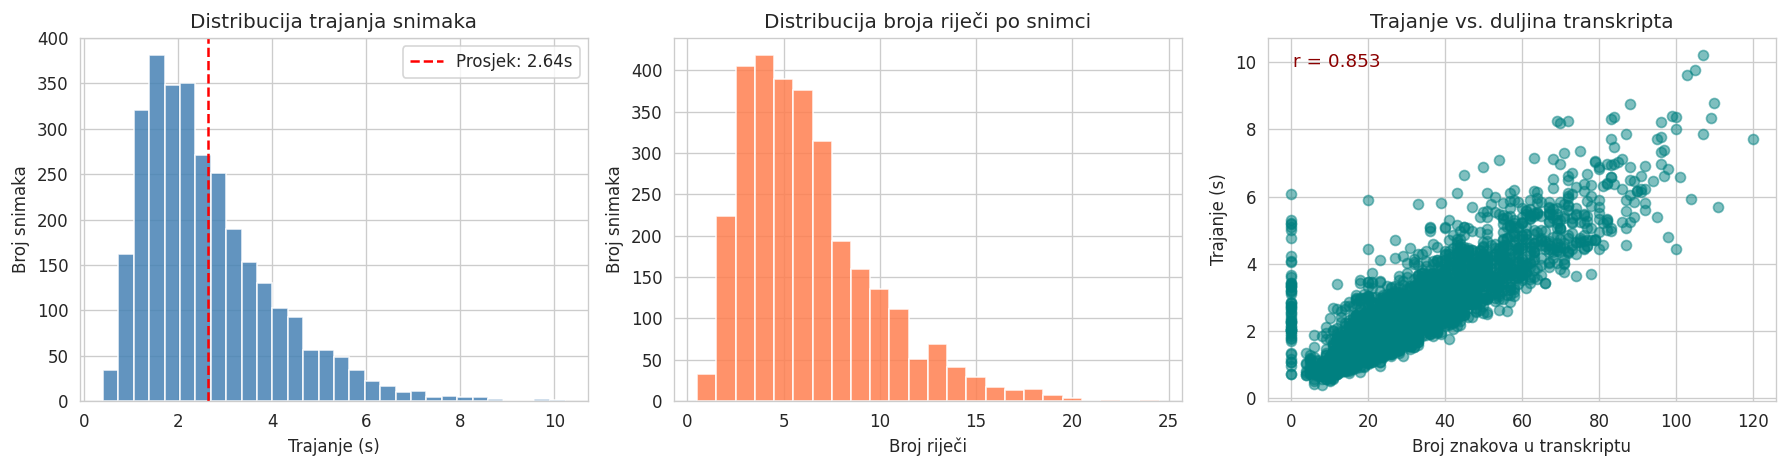

Korelacija trajanje–br. znakova: r=0.853


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram trajanja
axes[0].hist(df['duration'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['duration'].mean(), color='red', linestyle='--', label=f'Prosjek: {df["duration"].mean():.2f}s')
axes[0].set_xlabel('Trajanje (s)')
axes[0].set_ylabel('Broj snimaka')
axes[0].set_title('Distribucija trajanja snimaka')
axes[0].legend()

# Histogram broja riječi
axes[1].hist(df['n_words'], bins=range(1, df['n_words'].max()+2),
             color='coral', edgecolor='white', alpha=0.85, align='left')
axes[1].set_xlabel('Broj riječi')
axes[1].set_ylabel('Broj snimaka')
axes[1].set_title('Distribucija broja riječi po snimci')

# Scatterplot: trajanje vs. broj znakova
axes[2].scatter(df['n_chars'], df['duration'], alpha=0.5, color='teal')
axes[2].set_xlabel('Broj znakova u transkriptu')
axes[2].set_ylabel('Trajanje (s)')
axes[2].set_title('Trajanje vs. duljina transkripta')

# Korelacija
corr = df['n_chars'].corr(df['duration'])
axes[2].text(0.05, 0.92, f'r = {corr:.3f}', transform=axes[2].transAxes,
             fontsize=11, color='darkred')

plt.tight_layout()
plt.savefig('results/eda_distributions.png', bbox_inches='tight')
plt.show()
print(f'Korelacija trajanje–br. znakova: r={corr:.3f}')

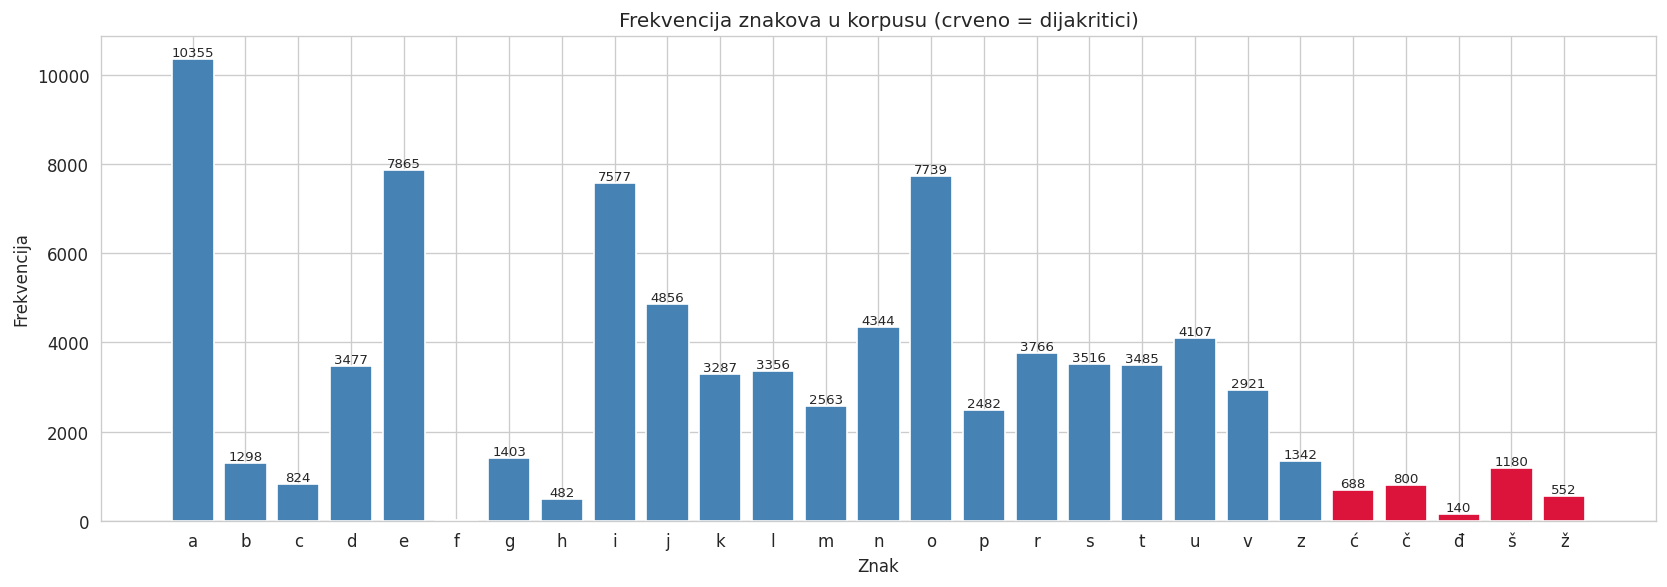


Frekvencija dijakritičkih znakova:
  š: 1180
  č: 800
  ć: 688
  ž: 552
  đ: 140

Snimaka s dijakritikama: 1944 / 3069


In [6]:
from collections import Counter

all_text = ' '.join(df['text'])
char_freq = Counter(all_text)
del char_freq[' ']  # ukloni razmak za prikaz

chars  = sorted(char_freq.keys())
counts = [char_freq[c] for c in chars]
colors = ['crimson' if c in 'šđčćž' else 'steelblue' for c in chars]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(chars, counts, color=colors, edgecolor='white')
ax.set_xlabel('Znak')
ax.set_ylabel('Frekvencija')
ax.set_title('Frekvencija znakova u korpusu (crveno = dijakritici)')

for bar, count in zip(bars, counts):
    if count > 50:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('results/eda_char_freq.png', bbox_inches='tight')
plt.show()

diacritics = {c: char_freq.get(c, 0) for c in 'šđčćž'}
print('\nFrekvencija dijakritičkih znakova:')
for ch, cnt in sorted(diacritics.items(), key=lambda x: -x[1]):
    print(f'  {ch}: {cnt}')
print(f'\nSnimaka s dijakritikama: {df["has_diacritics"].sum()} / {len(df)}')

## 2. Vizualizacija spektrograma

/home/dino/Documents/V2/ds2_projekt/ds2_projekt/.venv/lib/python3.12/site-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (257) may be set too low.
  warnings.warn(
/home/dino/Documents/V2/ds2_projekt/ds2_projekt/.venv/lib/python3.12/site-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (257) may be set too low.
  warnings.warn(
/home/dino/Documents/V2/ds2_projekt/ds2_projekt/.venv/lib/python3.12/site-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (257) may be set too low.
  warnings.warn(


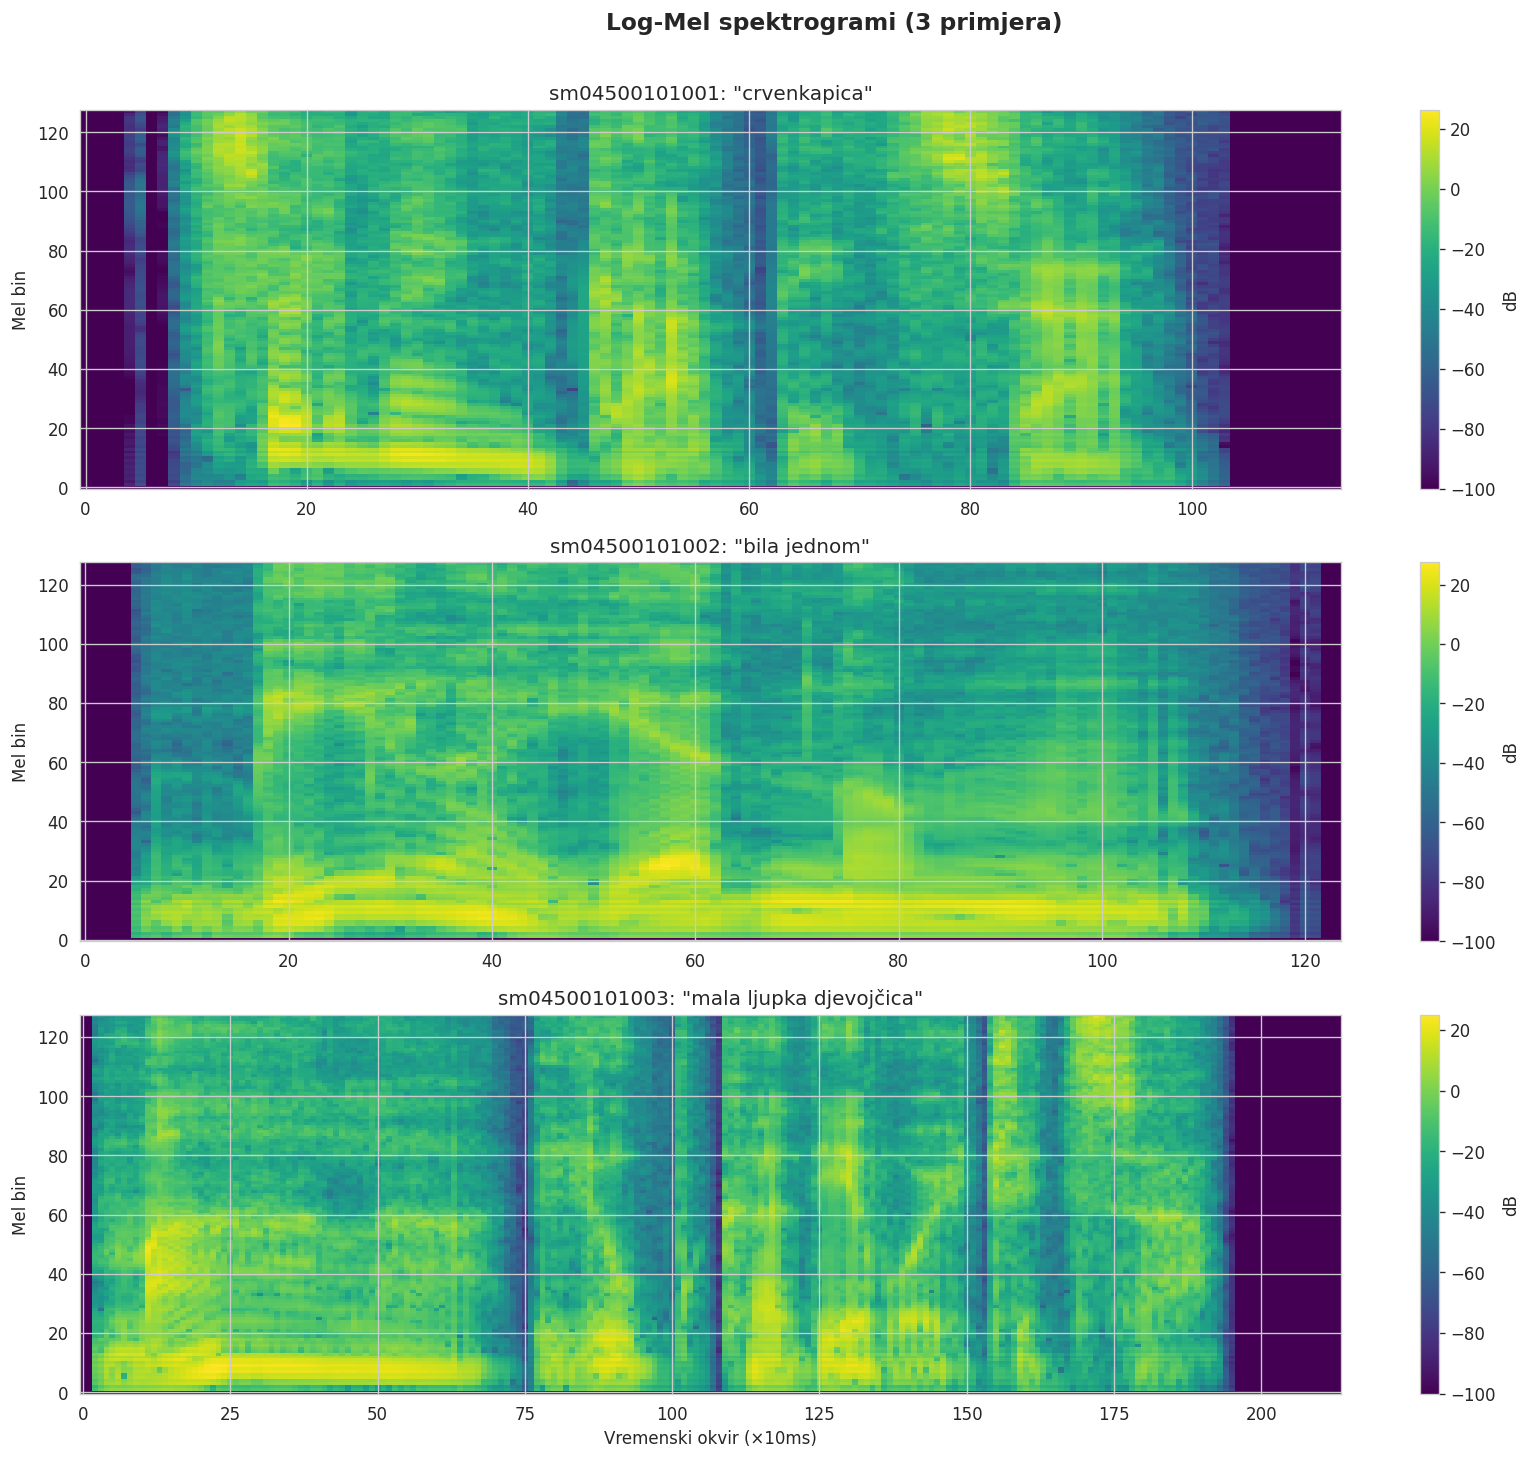

Spektrogrami vizualizirani!


In [7]:
wav_files = sorted(AUDIO_DIR.glob('*.wav'))

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for i, wav_file in enumerate(wav_files[:3]):
    waveform, sr = torchaudio.load(str(wav_file))
    stem = wav_file.stem
    
    mel_transform = T.MelSpectrogram(
        sample_rate=16000, n_fft=512,
        win_length=320, hop_length=160, n_mels=128
    )
    amp_to_db = T.AmplitudeToDB()
    
    spec = amp_to_db(mel_transform(waveform[0]))
    
    txt = df[df['stem'] == stem]['text'].values
    title = f'{stem}: "{txt[0]}"' if len(txt) > 0 else stem
    
    im = axes[i].imshow(
        spec.numpy(), origin='lower', aspect='auto',
        cmap='viridis', interpolation='nearest'
    )
    axes[i].set_title(title, fontsize=12)
    axes[i].set_ylabel('Mel bin')
    if i == 2:
        axes[i].set_xlabel('Vremenski okvir (×10ms)')
    
    plt.colorbar(im, ax=axes[i], label='dB')

plt.suptitle('Log-Mel spektrogrami (3 primjera)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/spectrograms.png', bbox_inches='tight')
plt.show()
print('Spektrogrami vizualizirani!')

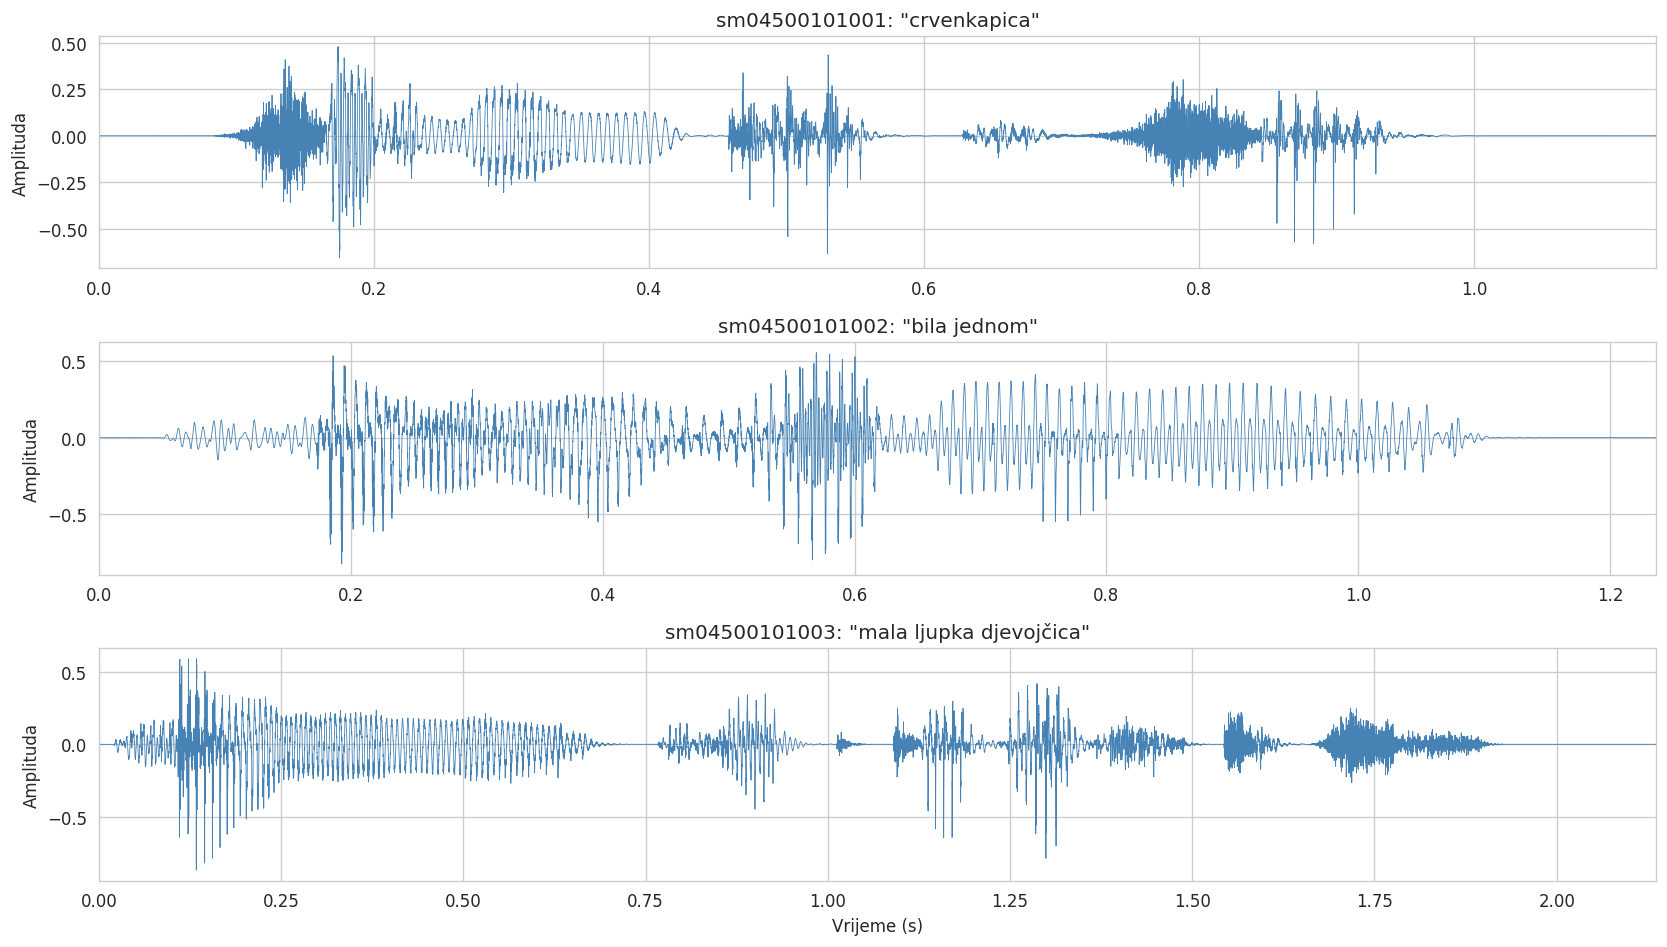

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

for i, wav_file in enumerate(wav_files[:3]):
    waveform, sr = torchaudio.load(str(wav_file))
    stem = wav_file.stem
    t = np.linspace(0, waveform.shape[-1]/sr, waveform.shape[-1])
    
    axes[i].plot(t, waveform[0].numpy(), color='steelblue', linewidth=0.5)
    axes[i].set_ylabel('Amplituda')
    
    txt = df[df['stem'] == stem]['text'].values
    axes[i].set_title(f'{stem}: "{txt[0] if len(txt) else ""}"')
    axes[i].set_xlim(0, t[-1])
    
    if i == 2:
        axes[i].set_xlabel('Vrijeme (s)')

plt.tight_layout()
plt.savefig('results/waveforms.png', bbox_inches='tight')
plt.show()

## 3. Analiza manifesta (train/dev/test split)

train :  2406 snimaka | 105.3 min
dev   :   300 snimaka | 13.0 min
test  :   302 snimaka | 14.0 min


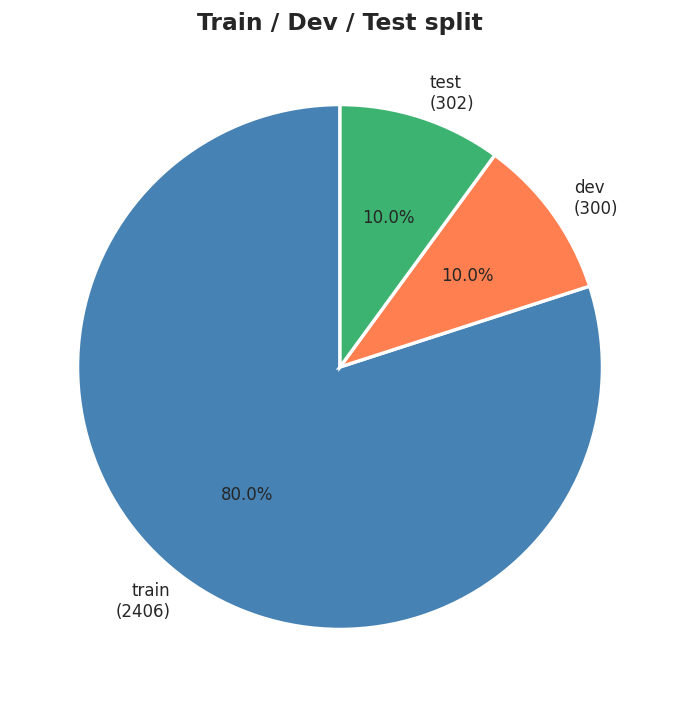

In [9]:
splits = {}
for split in ['train', 'dev', 'test']:
    manifest = Path(f'data/processed/{split}/manifest.csv')
    if manifest.exists():
        splits[split] = pd.read_csv(manifest)
        print(f'{split:6s}: {len(splits[split]):5d} snimaka | '
              f'{splits[split]["duration"].sum()/60:.1f} min')
    else:
        print(f'{split}: manifest ne postoji — pokreni scripts/prepare_data.sh')

if splits:

    sizes  = [len(v) for v in splits.values()]
    labels = [f'{k}\n({n})' for k, n in zip(splits.keys(), sizes)]
    
    fig, ax = plt.subplots(figsize=(6, 6))
    colors  = ['steelblue', 'coral', 'mediumseagreen']
    wedges, texts, autotexts = ax.pie(
        sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    ax.set_title('Train / Dev / Test split', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('results/data_split.png', bbox_inches='tight')
    plt.show()

## 4. Vizualizacija rezultata treniranja

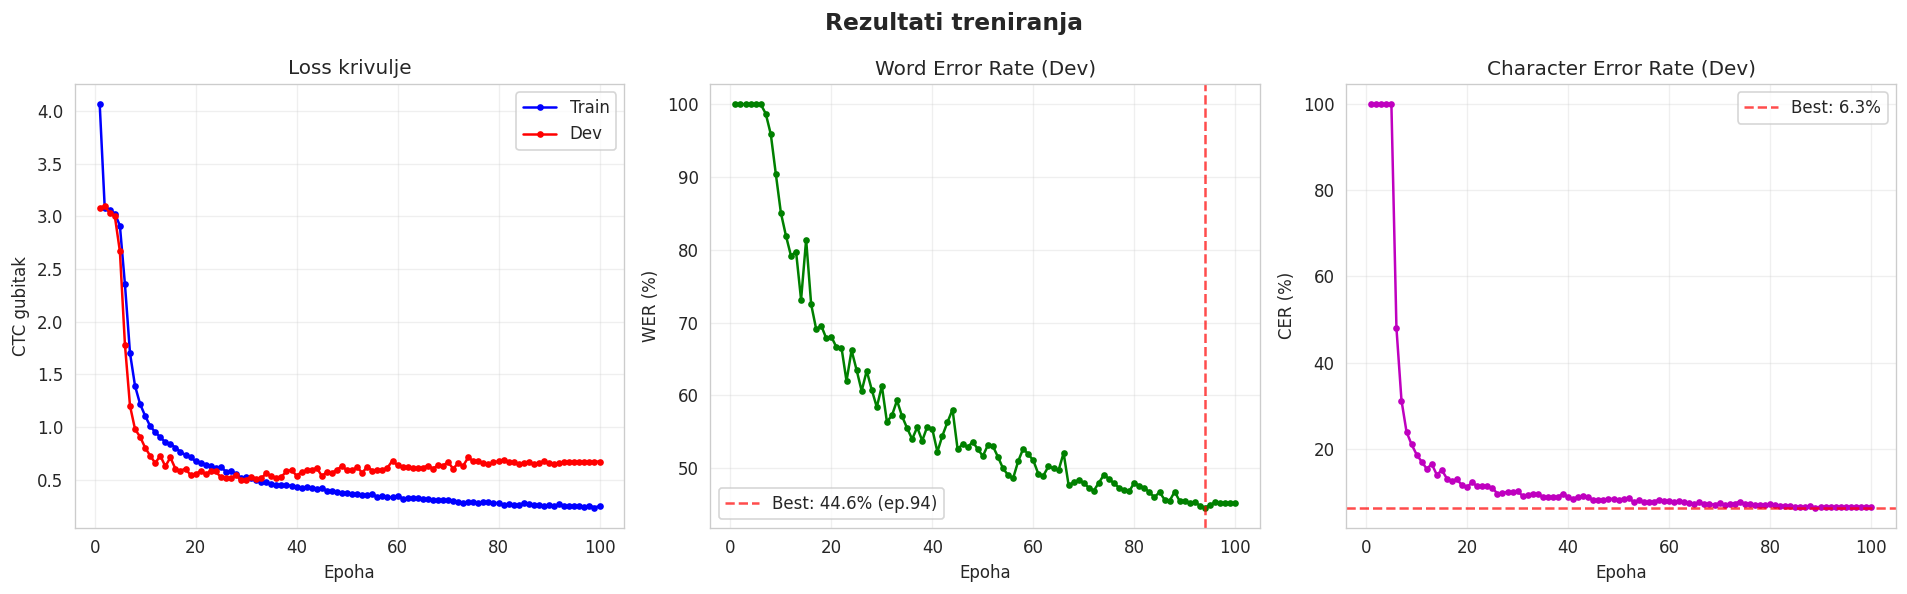

Best Dev WER: 44.60%
Test WER:     41.37245151665838
Test CER:     5.317111636814239


In [10]:
results_file = Path('results/training_results.json')

if results_file.exists():
    with open(results_file) as f:
        results = json.load(f)
    
    history = results['history']
    epochs  = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=3, label='Train')
    axes[0].plot(epochs, history['dev_loss'],   'r-o', markersize=3, label='Dev')
    axes[0].set_xlabel('Epoha')
    axes[0].set_ylabel('CTC gubitak')
    axes[0].set_title('Loss krivulje')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(epochs, history['dev_wer'], 'g-o', markersize=3)
    min_wer = min(history['dev_wer'])
    min_ep  = history['dev_wer'].index(min_wer) + 1
    axes[1].axvline(min_ep, color='red', linestyle='--', alpha=0.7,
                    label=f'Best: {min_wer:.1f}% (ep.{min_ep})')
    axes[1].set_xlabel('Epoha')
    axes[1].set_ylabel('WER (%)')
    axes[1].set_title('Word Error Rate (Dev)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(epochs, history['dev_cer'], 'm-o', markersize=3)
    min_cer = min(history['dev_cer'])
    axes[2].axhline(min_cer, color='red', linestyle='--', alpha=0.7,
                    label=f'Best: {min_cer:.1f}%')
    axes[2].set_xlabel('Epoha')
    axes[2].set_ylabel('CER (%)')
    axes[2].set_title('Character Error Rate (Dev)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle('Rezultati treniranja', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('results/training_curves.png', bbox_inches='tight')
    plt.show()
    
    print(f'Best Dev WER: {results["best_dev_wer"]:.2f}%')
    print(f'Test WER:     {results.get("test_wer", "N/A")}')
    print(f'Test CER:     {results.get("test_cer", "N/A")}')
else:
    print('training_results.json ne postoji — treniranje još nije pokrenuto.')
    print('Pokreni: python src/train.py --config configs/training_config.json')

## 5. Analiza grešaka

Ukupno test uzoraka: 302
Točnih transkripta:  57
Avg WER:  40.2%
Avg CER:  5.4%

Najteži primjeri (najviši WER):


,file,reference,hypothesis,wer,cer
87,sm04500601037,nisam,mni sam,200.0,20.0
299,sm04500101110,ne mogu ustati,ne mo gu stadtie,100.0,25.0
240,sm04500301030,sjašite sami,sjaši te sami,100.0,0.0
45,sm04500604009,pak carsku jabuku s križem,pakcasku jabu kuskrižem,100.0,4.5
176,sm04500603100,svuda sjaj i blistavilo svuda zlato,svoja sjaji bli stavilo suda zlatoji,100.0,16.7
278,sm04501002050,hodi sa mnom,kodji zamnom,100.0,30.0
233,sm04500201005,uto naiđe niz ulicu nekakva seljakinja,u tonajiđe nizulicu nekaka se ljakinja,100.0,6.1
84,sm04500605014,u tome,utome,100.0,0.0
281,sm04500101116,i proždera baku,i prožde ra bak,100.0,7.7
82,sm04500401039,ubra na brzinu punu šaku matovilca te ga dones...,ubrana brazinu punušakoumato vilca te gadonese...,90.0,4.7



Greške s dijakritikama: 12 / 302


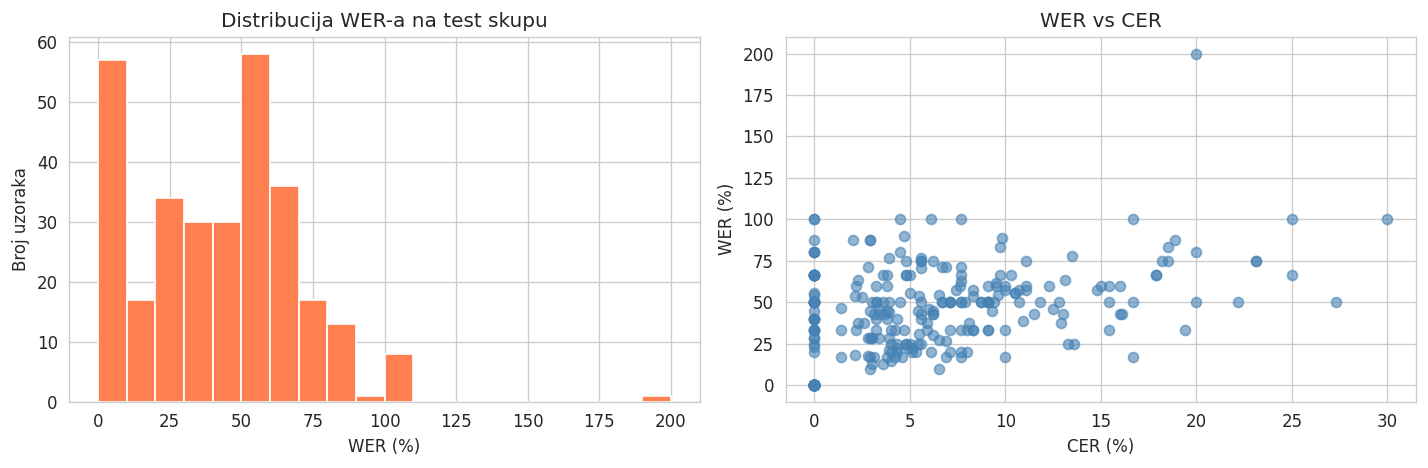

In [11]:
test_csv = Path('results/test_results.csv')

if test_csv.exists():
    test_df = pd.read_csv(test_csv)
    
    print(f'Ukupno test uzoraka: {len(test_df)}')
    print(f'Točnih transkripta:  {(test_df["wer"]==0).sum()}')
    print(f'Avg WER:  {test_df["wer"].mean():.1f}%')
    print(f'Avg CER:  {test_df["cer"].mean():.1f}%')
    print()
    
    worst = test_df.sort_values('wer', ascending=False).head(10)
    print('Najteži primjeri (najviši WER):')
    display(worst[['file','reference','hypothesis','wer','cer']])
    
    def has_diacritic_error(ref, hyp):
        diacritics = set('šđčćž')
        ref_d = [c for c in ref if c in diacritics]
        hyp_d = [c for c in hyp if c in diacritics]
        return ref_d != hyp_d
    
    test_df['diacritic_error'] = test_df.apply(
        lambda r: has_diacritic_error(str(r['reference']), str(r['hypothesis'])), axis=1
    )
    n_diac_err = test_df['diacritic_error'].sum()
    print(f'\nGreške s dijakritikama: {n_diac_err} / {len(test_df)}')
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].hist(test_df['wer'], bins=20, color='coral', edgecolor='white')
    axes[0].set_xlabel('WER (%)')
    axes[0].set_ylabel('Broj uzoraka')
    axes[0].set_title('Distribucija WER-a na test skupu')
    
    axes[1].scatter(test_df['cer'], test_df['wer'], alpha=0.6, color='steelblue')
    axes[1].set_xlabel('CER (%)')
    axes[1].set_ylabel('WER (%)')
    axes[1].set_title('WER vs CER')
    
    plt.tight_layout()
    plt.savefig('results/error_analysis.png', bbox_inches='tight')
    plt.show()
else:
    print('test_results.csv ne postoji — pokreni evaluaciju:')
    print('python src/evaluate.py --model models/best_model.pth --manifest data/processed/test/manifest.csv')

In [12]:
print('=' * 60)
print('SAŽETAK PROJEKTA')
print('=' * 60)
print(f'Korpus:')
print(f'  Ukupno snimaka:     {len(df)}')
print(f'  Ukupno trajanje:    {df.duration.sum()/60:.1f} min')
print(f'  Govornici:          1 (sm045)')
print(f'  Jezik:              Hrvatski')
print(f'  Sadržaj:            Bajka Crvenkapica')
print()
print('Tehničke karakteristike:')
print(f'  Format:             WAV, PCM 16-bit')
print(f'  Sample rate:        16000 Hz')
print(f'  Kanali:             Mono')
print()
print('Normalizacija:')
print('  Kodna stranica:     ISO-8859-2 → UTF-8')
print('  Dijakritici:        {, ~, ^, ` → š, č, đ, ž')
print('  Tišina:             <sil> uklonjena')

SAŽETAK PROJEKTA
Korpus:
  Ukupno snimaka:     3069
  Ukupno trajanje:    135.1 min
  Govornici:          1 (sm045)
  Jezik:              Hrvatski
  Sadržaj:            Bajka Crvenkapica

Tehničke karakteristike:
  Format:             WAV, PCM 16-bit
  Sample rate:        16000 Hz
  Kanali:             Mono

Normalizacija:
  Kodna stranica:     ISO-8859-2 → UTF-8
  Dijakritici:        {, ~, ^, ` → š, č, đ, ž
  Tišina:             <sil> uklonjena
